<a href="https://colab.research.google.com/github/apester/TDA/blob/main/TDA_ECG_Statistics_Graphs_TDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Example: Statistics, Graph Theory, and Topological Data Analysis

This notebook accompanies the **ECG mathematical extension** slides and compares three analytical views on a time series:

1. **Statistical analysis**
2. **Graph-theoretic analysis**
3. **Topological Data Analysis (TDA)**

The goal is not full clinical ECG processing, but a **master-level, mathematically meaningful worked example** that shows how the three approaches reveal different aspects of the same signal.

---
## What this notebook contains
- installation commands
- synthetic ECG-like signal generation
- RR-interval style statistical descriptors
- graph construction from sliding windows
- Takens / delay embedding
- persistent homology with a barcode / persistence diagram
- interpretation and comparison

## 0. Install the required libraries

Run the next cell once if the libraries are not already installed.

In [ ]:
# Install all required libraries
!pip install numpy matplotlib scipy scikit-learn networkx ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=c5222eecd998065bcd4e2e47e89ed54ad36c6e7e2db8164ef31284398a840a28
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


## 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.signal import find_peaks
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import kneighbors_graph
from ripser import ripser
from persim import plot_diagrams

plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(42)

## 2. Generate a synthetic ECG-like signal

For teaching purposes we generate a simple ECG-like waveform with:
- a repeating rhythm
- optional variability in beat spacing
- optional mild noise

This is enough to demonstrate the mathematics of the three approaches.

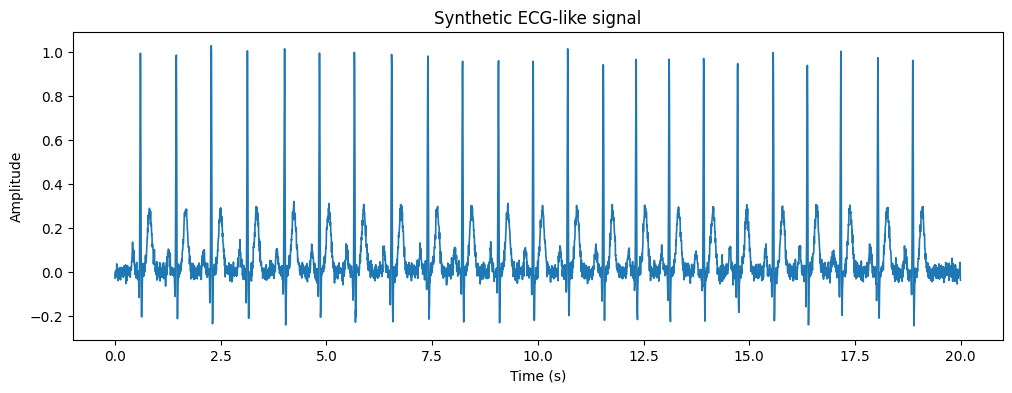

In [ ]:
def gaussian_pulse(t, center, width, amplitude):
    return amplitude * np.exp(-0.5 * ((t - center) / width) ** 2)

def synthetic_ecg(duration=20.0, fs=200, hr_mean=72, rr_jitter=0.03, noise_std=0.02):
    t = np.arange(0, duration, 1 / fs)
    signal = np.zeros_like(t)

    mean_rr = 60.0 / hr_mean
    beat_times = []
    current = 0.6

    while current < duration - 0.6:
        beat_times.append(current)
        rr = mean_rr + np.random.normal(0, rr_jitter)
        rr = max(0.5, rr)
        current += rr

    for bt in beat_times:
        # P wave
        signal += gaussian_pulse(t, bt - 0.18, 0.025, 0.10)
        # Q wave
        signal += gaussian_pulse(t, bt - 0.03, 0.008, -0.12)
        # R wave
        signal += gaussian_pulse(t, bt, 0.010, 1.00)
        # S wave
        signal += gaussian_pulse(t, bt + 0.025, 0.010, -0.25)
        # T wave
        signal += gaussian_pulse(t, bt + 0.22, 0.050, 0.28)

    signal += noise_std * np.random.randn(len(t))
    return t, signal, np.array(beat_times)

t, ecg, true_beats = synthetic_ecg()

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, lw=1.2)
plt.title("Synthetic ECG-like signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

## 3. Statistical analysis

We start with classical summary analysis.

### Mathematical idea
Let the detected R-peak times be

\[
t_1, t_2, \dots, t_m
\]

Then the RR intervals are

\[
RR_i = t_{i+1} - t_i
\]

and we can compute:
- mean RR interval
- mean heart rate
- variance / standard deviation of RR intervals
- simple heart-rate variability (HRV) style summaries

In [ ]:
peaks, props = find_peaks(ecg, height=0.5, distance=80)
peak_times = t[peaks]
rr = np.diff(peak_times)

mean_rr = np.mean(rr)
std_rr = np.std(rr)
mean_hr = 60.0 / mean_rr

print(f"Detected peaks: {len(peak_times)}")
print(f"Mean RR interval: {mean_rr:.4f} s")
print(f"Std RR interval:  {std_rr:.4f} s")
print(f"Estimated mean HR: {mean_hr:.2f} bpm")

Detected peaks: 23
Mean RR interval: 0.8305 s
Std RR interval:  0.0285 s
Estimated mean HR: 72.25 bpm


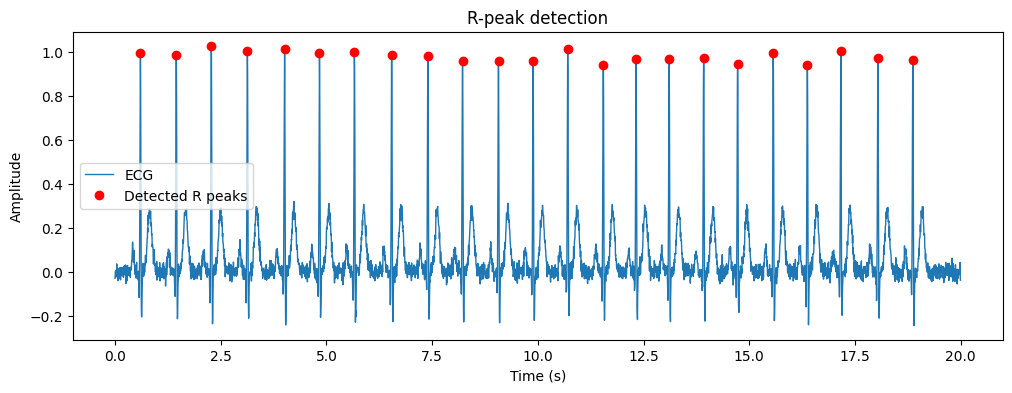

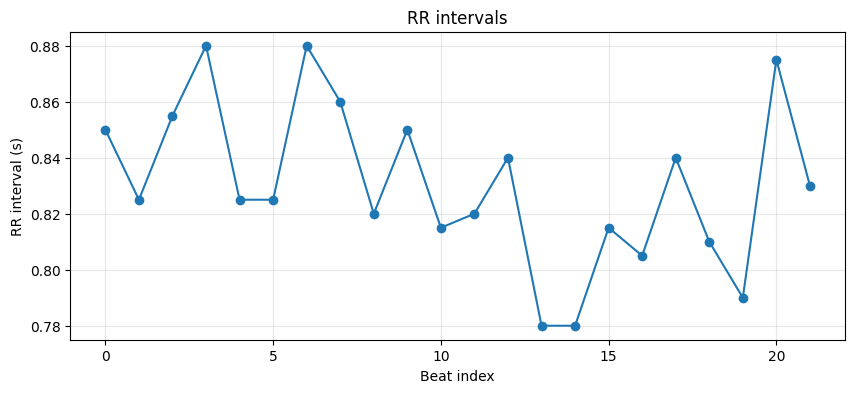

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, ecg, lw=1.0, label="ECG")
plt.plot(peak_times, ecg[peaks], "ro", label="Detected R peaks")
plt.title("R-peak detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rr, marker="o")
plt.title("RR intervals")
plt.xlabel("Beat index")
plt.ylabel("RR interval (s)")
plt.grid(alpha=0.3)
plt.show()

### Interpretation

Statistics answers questions like:
- Is the rhythm fast or slow?
- Is it regular or variable?
- How much does beat timing fluctuate?

But it does **not** directly represent the **global dynamical shape** of the process.

## 4. Graph-theoretic analysis

We now convert the ECG into a set of local windows and connect similar windows in a graph.

### Mathematical idea
Let each short window of the signal be represented by a vector

\[
x_i \in \mathbb{R}^d
\]

We build a graph

\[
G = (V, E)
\]

where:
- each node corresponds to one window
- an edge connects two nodes if the windows are sufficiently similar
- for example, by k-nearest neighbors

This reveals **relational structure**:
- similar beat shapes
- possible state clusters
- transitions between regimes

In [ ]:
def make_windows(signal, window_size=60, step=20):
    windows = []
    starts = []
    for start in range(0, len(signal) - window_size, step):
        windows.append(signal[start:start + window_size])
        starts.append(start)
    return np.array(windows), np.array(starts)

windows, starts = make_windows(ecg, window_size=60, step=20)
print("Window matrix shape:", windows.shape)

Window matrix shape: (197, 60)


In [ ]:
# Build a k-NN graph on the windows
k = 4
A = kneighbors_graph(windows, n_neighbors=k, mode="connectivity", include_self=False)
G = nx.from_scipy_sparse_array(A)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

degrees = [d for _, d in G.degree()]
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Connected components: {nx.number_connected_components(G)}")

Nodes: 197
Edges: 467
Average degree: 4.74
Connected components: 3


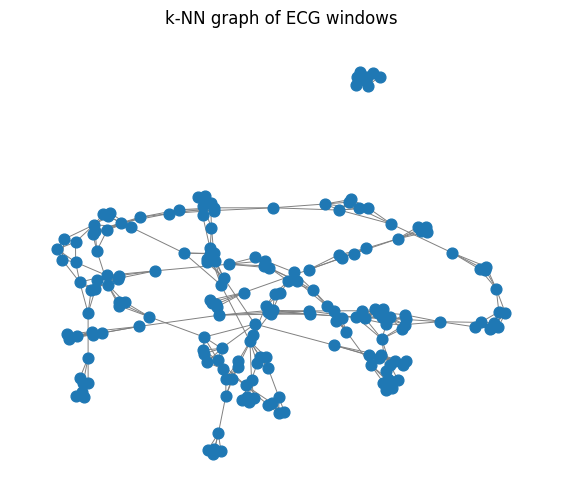

In [ ]:
plt.figure(figsize=(7, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos=pos,
    node_size=60,
    with_labels=False,
    edge_color="gray",
    width=0.7
)
plt.title("k-NN graph of ECG windows")
plt.axis("off")
plt.show()

### Interpretation

Graph theory now answers questions like:
- Which windows look alike?
- Are there communities of repeated beat patterns?
- Are there unusual windows that connect weakly?

This is already richer than plain statistics, because relationships matter.

## 5. Delay embedding / Takens embedding

To move toward TDA, we first turn the time series into a point cloud.

### Mathematical idea
For embedding dimension \(m\) and delay \(\tau\), define

\[
X_i = (x_i, x_{i+\tau}, x_{i+2\tau}, \dots, x_{i+(m-1)\tau})
\]

This reconstructs a geometric state-space view of the dynamics.

For approximately periodic signals, the embedded point cloud often traces a
**loop-like structure**.

In [ ]:
def delay_embedding(signal, m=3, tau=8):
    n = len(signal) - (m - 1) * tau
    embedded = np.empty((n, m))
    for i in range(n):
        embedded[i] = [signal[i + j * tau] for j in range(m)]
    return embedded

X = delay_embedding(ecg, m=3, tau=8)
print("Embedded point cloud shape:", X.shape)

Embedded point cloud shape: (3984, 3)


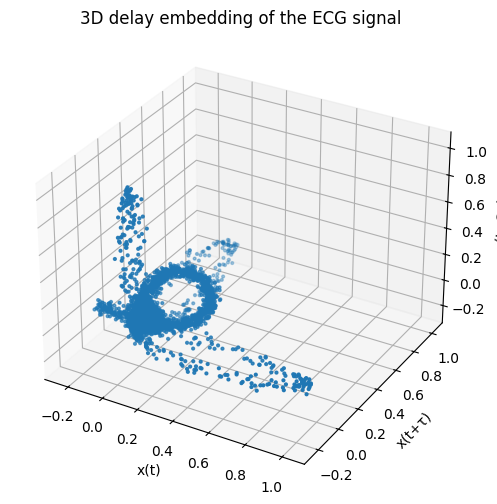

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=4)
ax.set_title("3D delay embedding of the ECG signal")
ax.set_xlabel("x(t)")
ax.set_ylabel("x(t+τ)")
ax.set_zlabel("x(t+2τ)")
plt.show()

## 6. Topological Data Analysis with persistent homology

We now apply persistent homology to the embedded point cloud.

### Mathematical idea
From the point cloud \(X\), construct a Vietoris–Rips filtration:
- at small radius \(\varepsilon\), only nearby points connect
- as \(\varepsilon\) grows, edges, triangles, and higher simplices appear
- homology tracks topological features across scale

In particular:
- \(H_0\): connected components
- \(H_1\): loops

A periodic ECG-like rhythm often induces a relatively persistent **1-dimensional loop**.

In [ ]:
# Subsample a bit for speed and clarity
X_sub = X[::3]

diagrams = ripser(X_sub, maxdim=1)["dgms"]
diagrams

[array([[0.        , 0.00048247],
        [0.        , 0.00089065],
        [0.        , 0.00106761],
        ...,
        [0.        , 0.10405109],
        [0.        , 0.13288404],
        [0.        ,        inf]]),
 array([[0.17417668, 0.197914  ],
        [0.16192782, 0.16599533],
        [0.15574178, 0.19008204],
        ...,
        [0.00650683, 0.00847797],
        [0.0061603 , 0.00706277],
        [0.00462142, 0.00503431]])]

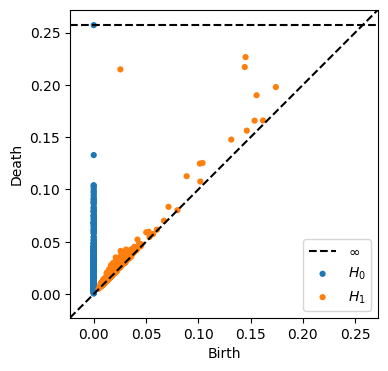

In [ ]:
plot_diagrams(diagrams, show=True)
plt.show()

### Reading the persistence diagram

- Points in dimension 0 correspond to connected components.
- Points in dimension 1 correspond to loops.
- A point farther from the diagonal has larger persistence.

So a clear H₁ point away from the diagonal supports the interpretation:
**the ECG dynamics contain a stable cyclic structure**.

## 7. Side-by-side comparison

### Statistical view
Captures:
- mean heart rate
- variance of RR intervals
- HRV-style summaries

Best for:
- fast screening
- simple descriptors
- direct numeric interpretation

### Graph view
Captures:
- similarity structure among windows
- clusters / communities
- transition structure

Best for:
- relational understanding
- repeated local patterns
- detecting unusual segments

### TDA view
Captures:
- global geometric structure of the dynamics
- loop-like periodicity across scale
- robustness of topological features

Best for:
- revealing dynamical shape
- comparing structurally similar vs different signals
- going beyond local summaries

In [ ]:
summary = {
    "Statistics": [
        f"mean RR = {mean_rr:.4f} s",
        f"std RR  = {std_rr:.4f} s",
        f"mean HR = {mean_hr:.2f} bpm",
    ],
    "Graph theory": [
        f"nodes = {G.number_of_nodes()}",
        f"edges = {G.number_of_edges()}",
        f"components = {nx.number_connected_components(G)}",
    ],
    "TDA": [
        "Persistent homology computed on delay embedding",
        "H1 features reflect cyclic / loop-like structure",
        "Distance from diagonal indicates persistence",
    ],
}

for method, items in summary.items():
    print(f"\n{method}")
    for item in items:
        print(" -", item)


Statistics
 - mean RR = 0.8305 s
 - std RR  = 0.0285 s
 - mean HR = 72.25 bpm

Graph theory
 - nodes = 197
 - edges = 467
 - components = 3

TDA
 - Persistent homology computed on delay embedding
 - H1 features reflect cyclic / loop-like structure
 - Distance from diagonal indicates persistence


## 8. Optional self-directed extensions

Try the following:
1. Increase the noise level in `synthetic_ecg`.
2. Increase `rr_jitter` to simulate more rhythm variability.
3. Change the delay embedding parameters `m` and `tau`.
4. Compare the persistence diagram before and after increasing irregularity.
5. Replace the synthetic ECG with a real ECG segment if you have one available.

These extensions make a good bridge from introductory TDA intuition to research-style experimentation.

## 9. Final takeaway

On ECG data:
- **statistics** summarizes
- **graph theory** relates
- **TDA** reveals shape

They are not rivals. They answer different mathematical questions about the same signal.